# 05 · Calibration on Freddie Mac loan-level history

**Purpose.** Replace the placeholder parameters of the prepayment and credit models with values estimated from real mortgage performance, so that the projections in notebooks 02–04 and the tranche analysis rest on data.

**Data (all kept local, never committed).**
- **Freddie Mac Single-Family Loan-Level Dataset, sample files**: 50,000 loans per origination year, 2000–2026, with monthly performance through 2026. Only 30-year fixed-rate loans are kept, to match STACR / CAS. Files: `data/raw/freddie_sf/`.
- **Freddie PMMS 30-year rate** (FRED `MORTGAGE30US`): the market rate that drives refinancing incentive.
- **FHFA purchase-only national HPI** (FRED `HPIPONM226S`): rolls each loan's original LTV forward to a mark-to-market LTV.

**Process.**
1. `src/freddie.py` reads the pipe-delimited files and builds one compact panel per vintage.
2. `src/calibration.run_all` reduces each vintage to small tables: SMM by (incentive, age, burnout) bucket, default spells by (LTV, FICO, DTI, occupancy) bucket, every liquidation's loss components, and the outcome of every 90+ day delinquency.
3. **Prepayment**: fit the model's S-curve formula to observed SMM (weighted least squares).
4. **Default**: Poisson GLM for the monthly probability that a current loan starts a default spell (its first missed payment on the way to 90+ days delinquent).
5. **Pipeline**: months from first missed payment to liquidation, the share of spells never liquidated, and modification rate cuts.
6. **Severity**: costs and mortgage insurance observed directly; the distressed-sale discount fitted so the model's severity matches actual losses.
7. Write the fitted values into `PARAMS` in `src/prepayment.py` and `src/credit_model.py`, and compare the STACR projections before and after.

In [1]:
import sys, warnings, pickle
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", "{:,.4f}".format)

from src import freddie as fr, calibration as cal, prepayment as pp, credit_model as cm
from src import collateral_projection as cp

**Q&A · Setup**

**Q: Why does the first cell search upward for a folder containing `src/`?**
A: The model code lives in `src/` at the repo root. Jupyter may start in the repo root or in `notebooks/`, so the cell walks up the folder tree until it finds `src/` and adds that folder to `sys.path`. Then `from src import ...` works wherever the notebook is opened.

**Q: Why are FutureWarnings turned off? Doesn't that hide problems?**
A: pandas 2.2 running on Python 3.14 prints spurious "chained assignment" warnings from `clean.py`, which drown out the real output. Only *warnings* are hidden. Real errors still stop the cell, so nothing that would make a result wrong is suppressed.

**Q: Which modules does this notebook use?**
A: `src/freddie.py` reads the Freddie files and FRED series, and `src/calibration.py` builds the tables and fits the models. The fitted numbers are then checked against `PARAMS` in `src/prepayment.py` and `src/credit_model.py`.

## 1 · Build the calibration tables

First run builds `data/processed/freddie/` panels (about 3 minutes); later runs take about 30 seconds.

In [2]:
hpi = fr.load_fred("HPIPONM226S")
pmms = fr.load_fred("MORTGAGE30US")
for y in fr.VINTAGES:
    fr.compact_panel(y)
r = cal.run_all(hpi, pmms)
print(f"prepay: {r['prepay']['n'].sum():,.0f} loan-months  |  default: {r['default']['n'].sum():,.0f} loan-months, "
      f"{r['default']['events'].sum():,.0f} default spells  |  liquidations: {len(r['liquidations']):,}")

prepay: 47,948,074 loan-months  |  default: 38,166,654 loan-months, 22,598 default spells  |  liquidations: 17,430


**Result · Data.** After keeping only 30-year fixed-rate loans, the fits use about **48 million loan-months** for prepayment, **38 million loan-months with 22,598 default spells** for default (COVID-forbearance months 2020-03 to 2021-12 are left out, since that "delinquency" mostly cured), and **17,430 liquidations** with full loss detail.

**Q&A · Building the calibration tables**

**Q: Why only 30-year fixed-rate loans?**
A: STACR DNA1 and CAS R01 reference pools are all 30-year fixed-rate loans. ARMs and 15-year loans prepay and default differently, so including them would bias the fit.

**Q: Why are COVID forbearance months (Mar 2020 – Dec 2021) left out of the default fit?**
A: During forbearance, missed payments were reported as delinquencies, but most of those borrowers resumed paying without a loss. Counting them as defaults would roughly double the fitted default rate (0.81% vs 0.40% a year when they're included) and understate the liquidation share.

**Q: Why reduce 48 million loan-months to buckets?**
A: The fits only need totals by bucket (exposure, prepaid dollars, defaults). Bucketing makes fitting fast and lets the notebook run on a laptop in about 30 seconds.

## 2 · Market inputs: PMMS rate and house prices

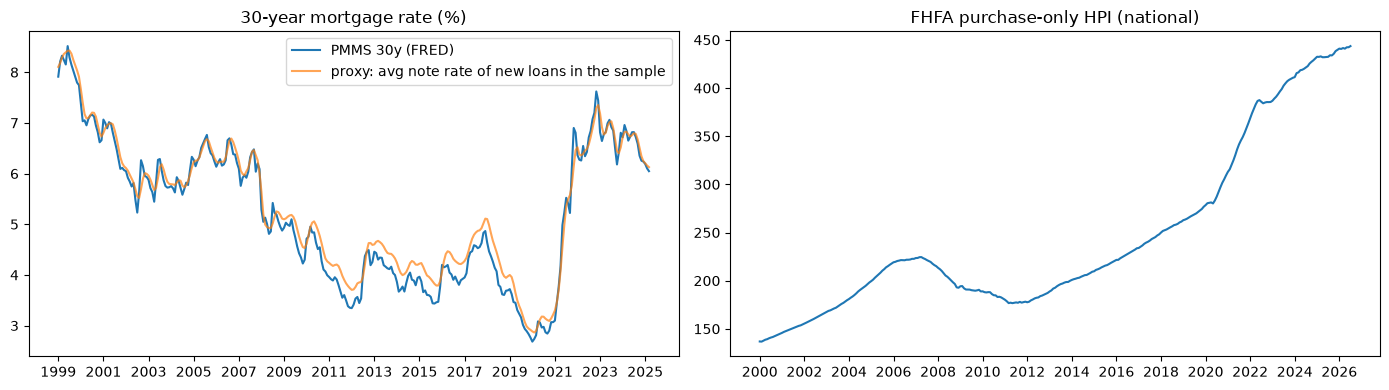

proxy - PMMS: mean 0.14 pp, corr 0.992
PMMS latest: {202608: 6.67, 202609: 6.86, 202610: 7.28}


In [3]:
proxy = fr.market_rate_proxy(fr.load_all_orig())
both = pd.concat([pmms, proxy], axis=1).dropna()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(len(both))
ax[0].plot(x, both["MORTGAGE30US"], label="PMMS 30y (FRED)")
ax[0].plot(x, both["market_rate"], label="proxy: avg note rate of new loans in the sample", alpha=0.7)
ticks = x[::24]; ax[0].set_xticks(ticks, [str(p)[:4] for p in both.index[::24]])
ax[0].set_title("30-year mortgage rate (%)"); ax[0].legend()
h = hpi.loc[200001:]
ax[1].plot(np.arange(len(h)), h.values); ax[1].set_xticks(np.arange(len(h))[::24], [str(p)[:4] for p in h.index[::24]])
ax[1].set_title("FHFA purchase-only HPI (national)")
plt.tight_layout(); plt.show()
print("proxy - PMMS: mean %.2f pp, corr %.3f" % ((both.market_rate - both.MORTGAGE30US).mean(), both.corr().iloc[0, 1]))
print("PMMS latest:", pmms.iloc[-3:].round(2).to_dict())

**Result · Market inputs.** The proxy (average note rate of new loans in the sample) tracks PMMS almost perfectly (**corr 0.992**, about 0.14 pp higher on average), so PMMS is a sound driver for the refinancing incentive. The HPI shows the 2006–2011 crash (about −20% nationally), which is what identifies how defaults and losses respond to negative equity. **PMMS is now 7.28%** (Oct 2026), up from about 6.05% in February.

**Q&A · Market inputs**

**Q: Why build a proxy rate from the loans if PMMS is available?**
A: As a check. If the average note rate of new loans in the sample didn't track PMMS, the incentive would be mismeasured. A correlation of 0.992, with the proxy about 0.14 pp higher (loan rates sit slightly above the survey rate), confirms PMMS is the right driver.

**Q: Why the FHFA purchase-only national index?**
A: It's monthly, back to 1991, based on actual sales (no appraisal refinances), and is published for free by FRED. Its limitation is that it's national: defaults cluster in regions that fell harder than the average.

## 3 · Prepayment fit

In [4]:
fit = cal.calibrate(r)
pd.Series(fit["prepayment"]).to_frame("fitted").join(
    pd.Series({"turnover": 0.06, "refi_max": 0.55, "midpoint": 0.75, "slope": 3.5, "burnout": 0.02,
               "ramp_months": 30}, name="placeholder"))

,fitted,placeholder
turnover,0.0551,0.0600
refi_max,0.4137,0.5500
midpoint,0.7144,0.7500
slope,2.7363,3.5000
burnout,0.0076,0.0200
ramp_months,6.2136,30.0000


weighted R^2 across 1,493 buckets: 0.910
observed vs fitted CPR at selected incentives:
 incentive  observed CPR  fitted CPR
   -3.4610        0.0420      0.0550
   -1.6280        0.0590      0.0560
   -1.1110        0.0650      0.0580
   -0.6180        0.0730      0.0660
   -0.1270        0.0870      0.0920
    0.3640        0.1770      0.1680
    0.8500        0.3710      0.2940
    1.3350        0.3270      0.3930


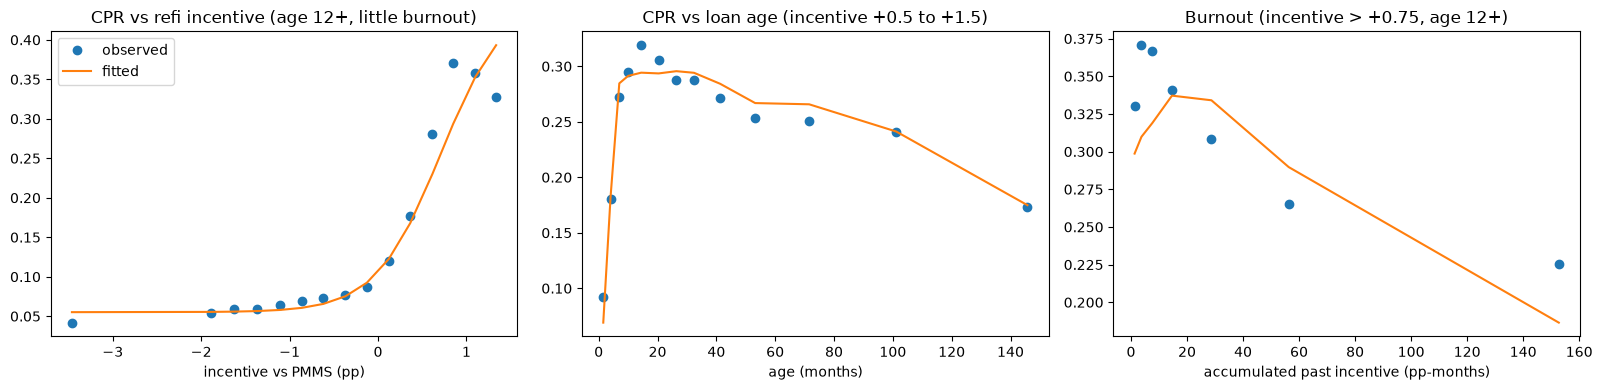

In [5]:
b = r["prepay"]; b = b[b["n"] >= 200].copy()
theta = list(fit["prepayment"].values())
b["fit"] = cal.prepay_model_smm(theta, b["inc"], b["age"], b["burn"])
r2 = 1 - np.average((b.smm - b.fit) ** 2, weights=b.w) / np.average((b.smm - np.average(b.smm, weights=b.w)) ** 2, weights=b.w)
print(f"weighted R^2 across {len(b):,} buckets: {r2:.3f}")

def by(df, key):
    g = df.assign(o=df.smm * df.w, f=df.fit * df.w).groupby(key)
    s = g[["o", "f", "w"]].sum()
    return pp.smm_to_cpr(s.o / s.w), pp.smm_to_cpr(s.f / s.w), g.apply(lambda d: np.average(d[key.replace("_b", "")], weights=d.w))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
seasoned = b[(b.age >= 12) & (b.burn < 5)]
o, f, xx = by(seasoned, "inc_b")
ax[0].plot(xx, o, "o", label="observed"); ax[0].plot(xx, f, "-", label="fitted")
ax[0].set_title("CPR vs refi incentive (age 12+, little burnout)"); ax[0].set_xlabel("incentive vs PMMS (pp)"); ax[0].legend()
o, f, xx = by(b[(b.inc > 0.5) & (b.inc < 1.5)], "age_b")
ax[1].plot(xx, o, "o"); ax[1].plot(xx, f, "-"); ax[1].set_title("CPR vs loan age (incentive +0.5 to +1.5)"); ax[1].set_xlabel("age (months)")
o, f, xx = by(b[(b.inc > 0.75) & (b.age >= 12)], "burn_b")
ax[2].plot(xx, o, "o"); ax[2].plot(xx, f, "-"); ax[2].set_title("Burnout (incentive > +0.75, age 12+)"); ax[2].set_xlabel("accumulated past incentive (pp-months)")
plt.tight_layout()
print("observed vs fitted CPR at selected incentives:")
o, f, xx = by(seasoned, "inc_b")
t = pd.DataFrame({"incentive": xx, "observed CPR": o, "fitted CPR": f})
print(t.iloc[::2].round(3).to_string(index=False))

**Result · Prepayment fit.** The fitted S-curve explains **91%** of the variation in bucket-level SMM (weighted R²). Compared with the placeholders:
- **turnover 5.5%** (was 6%): observed CPR far out of the money is about 4–6%
- **refi_max 41%** (was 55%) and **slope 2.7** (was 3.5): refinancing waves are real but less explosive than assumed
- **midpoint +0.71 pp** vs PMMS: the steep part is about 0.5–1 pp in the money, as in the data (CPR 18% at +0.4 pp, 37% at +0.85 pp)
- **burnout 0.0076** (was 0.02): burnout is real (the third plot falls with accumulated incentive) but gentler
- **seasoning ramp 6 months** (was PSA's 30): modern loans reach full speed within about half a year

The fit is weakest at the very top of refinancing waves (+0.85 pp observed 37% vs fitted 29%), where the 2003, 2012 and 2020–21 refi booms ran faster than any smooth curve.

**Q&A · Prepayment fit**

**Q: How is the S-curve fitted?**
A: Every current loan-month is placed in a bucket by incentive (0.25 pp steps), age and accumulated past incentive (burnout). For each bucket the observed SMM is prepaid dollars / exposure. Least squares then picks the six parameters that make the model's SMM closest to the observed SMM, weighting each bucket by its dollar exposure.

**Q: What does R² = 0.91 mean here?**
A: The fitted curve explains 91% of the dollar-weighted variation in bucket SMM across 1,493 buckets. The biggest misses are at the top of refinancing waves (2003, 2012, 2020–21), where real speeds briefly overshot any smooth curve.

**Q: Why is the seasoning ramp only 6 months when PSA uses 30?**
A: The PSA benchmark is from the 1980s. Modern borrowers refinance or move within months if it pays, and streamlined refinancing makes that cheap. The age plot shows CPR reaching its plateau in well under a year.

## 4 · Default fit (Poisson GLM)

In [6]:
glm = fit["diagnostics"]["glm"]
print(glm.summary().tables[1])
print("\npre-2009 vintages default", round(fit["diagnostics"]["pre2009_mult"], 2), "x more at the same LTV / FICO / DTI")
pd.Series({k: fit["credit"][k] for k in ["base_cdr", "b_ltv_low", "b_ltv_high", "b_fico", "b_dti", "investor_mult", "dq30_extra_mdr"]}).to_frame("fitted").join(
    pd.Series(cm.PARAMS).rename("now in credit_model.PARAMS"))

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.0117      0.016   -499.402      0.000      -8.043      -7.980
ltv_low        0.0209      0.001     38.721      0.000       0.020       0.022
ltv_high       0.0399      0.001     43.730      0.000       0.038       0.042
fico          -0.0091      0.000    -74.047      0.000      -0.009      -0.009
dti            0.0226      0.001     36.508      0.000       0.021       0.024
investor       0.2029      0.027      7.552      0.000       0.150       0.256
pre2009        0.9204      0.016     55.853      0.000       0.888       0.953

pre-2009 vintages default 2.51 x more at the same LTV / FICO / DTI


,fitted,now in credit_model.PARAMS
base_cdr,0.0040,0.0040
b_ltv_low,0.0209,0.0210
b_ltv_high,0.0399,0.0400
b_fico,0.0091,0.0091
b_dti,0.0226,0.0227
investor_mult,1.2249,1.2200
dq30_extra_mdr,0.0228,0.0228


                   n     events  observed  fitted
ltv_b                                            
50    2,717,234.0000   954.0000    0.4210  0.4180
60    3,272,018.0000 1,450.0000    0.5320  0.5660
70    3,767,385.0000 1,982.0000    0.6310  0.7320
80    2,650,564.0000 2,588.0000    1.1720  1.0260
90    1,602,096.0000 2,355.0000    1.7640  1.5870
100     230,220.0000   801.0000    4.1750  4.0660
110      67,240.0000   291.0000    5.1930  6.9440


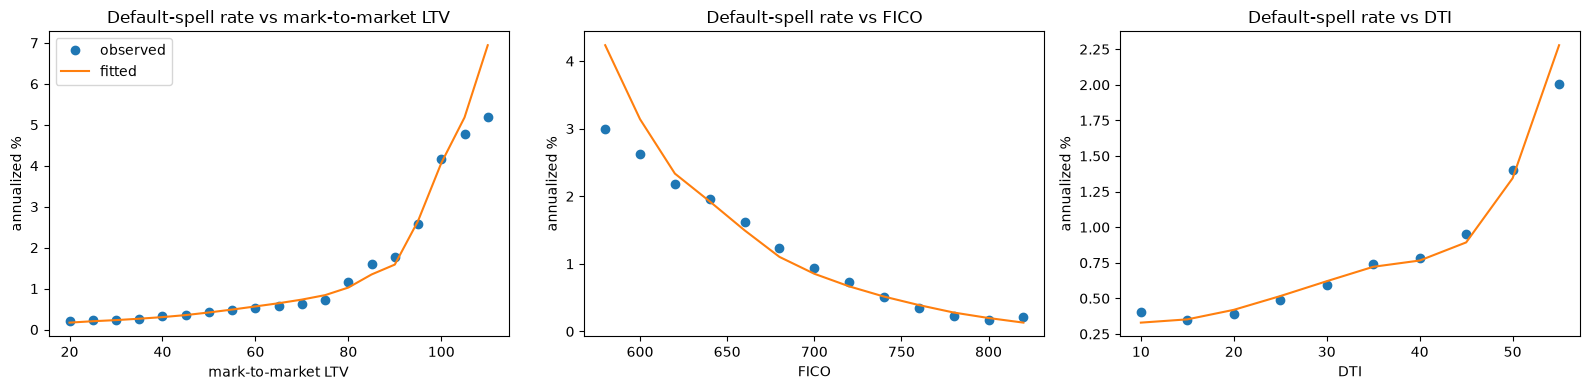

In [7]:
d = r["default"]
X = pd.DataFrame({"const": 1.0, "ltv_low": np.minimum(d.ltv - 80, 0), "ltv_high": np.maximum(d.ltv - 80, 0),
                  "fico": d.fico - 750, "dti": d.dti - 38, "investor": d.investor, "pre2009": d.pre2009})
d = d.assign(fit=glm.predict(X, offset=np.log(d.n)))
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, key, lab in [(ax[0], "ltv_b", "mark-to-market LTV"), (ax[1], "fico_b", "FICO"), (ax[2], "dti_b", "DTI")]:
    g = d.groupby(key)[["events", "fit", "n"]].sum(); g = g[g.n > 20000]
    a.plot(g.index, g.events / g.n * 1200, "o", label="observed"); a.plot(g.index, g.fit / g.n * 1200, "-", label="fitted")
    a.set_title(f"Default-spell rate vs {lab}"); a.set_ylabel("annualized %"); a.set_xlabel(lab)
ax[0].legend(); plt.tight_layout()
g = d.groupby("ltv_b")[["events", "fit", "n"]].sum(); g = g[g.n > 20000]
print((g.assign(observed=g.events / g.n * 1200, fitted=g.fit / g.n * 1200)[["n", "events", "observed", "fitted"]]).reindex([50, 60, 70, 80, 90, 100, 110, 120]).dropna().round(3))

**Result · Default fit.** Every coefficient has the expected sign and is precisely estimated (z-statistics 7–74):
- **LTV**: +2.1% per point below 80 and **+4.0% per point above 80**. The observed rate climbs from 0.42% a year at LTV 50 to 1.17% at 80 and **4.2% at 100**, and the fit tracks it.
- **FICO**: −0.9% per point, so a 700 borrower defaults about 1.6× as often as a 750 borrower.
- **DTI**: +2.3% per point. **Investor**: 1.22×.
- **Pre-2009 vintages**: 2.5× more default at the same LTV, FICO and DTI, which reflects pre-crisis underwriting. The base rate is set for **post-2008 vintages** (0.40% a year at LTV 80, FICO 750, DTI 38), matching STACR's 2024–25 loans.

**Q&A · Default fit**

**Q: What exactly is the "event" in the GLM?**
A: A current loan whose payment this month is the first of a run that reaches 90+ days delinquent (or a credit event). Its covariates are measured the month before. Loans already behind are excluded, because the model gives them a separate roll hazard.

**Q: Why include a pre-2009 indicator if the model doesn't use it?**
A: Pre-crisis loans had looser underwriting (low documentation, layered risk) not captured by FICO, LTV and DTI. Without the indicator, the base rate would absorb their 2.5× higher default rate and overstate risk for today's loans. The base rate is therefore taken for post-2008 vintages, like STACR's 2024–25 loans.

**Q: Where does the fit miss?**
A: At 70 LTV it slightly overpredicts (0.73% fitted vs 0.63% observed), and at 110+ LTV it overpredicts (6.9% vs 5.2%). The kink at 80 in a two-slope form can't match every bucket, but it captures the main pattern: defaults more than triple from LTV 80 to 100 (1.17% → 4.18% a year).

## 5 · Liquidation pipeline: timing, outcomes, 30-day roll

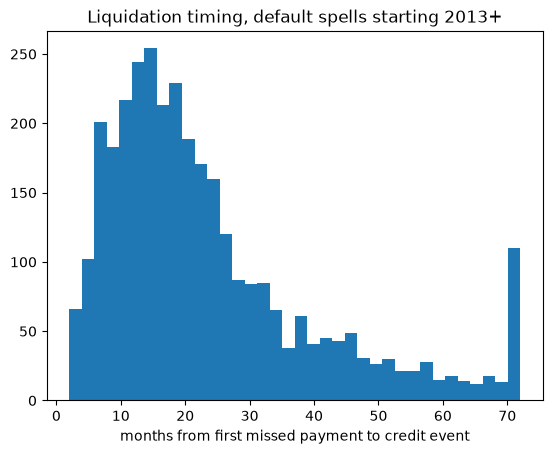

median months to credit event (2013+ spells): 19  (pre-2013 spells: 21)
share of 90+ spells liquidated: 43.0%;  modified: 37.0%;  rate cut if modified: 0.88 pp
loans 30 days late reaching 90+ within 12 months: 24.5%
credit events by type (2013+ spells): {'REO': 1241, 'third-party sale': 944, 'short sale': 616, 'note sale': 503}


In [8]:
diag = fit["diagnostics"]
liq = cal.clean_liquidations(r["liquidations"]); rec = liq[liq.start >= 201301]
plt.hist((rec.months_90_to_liq + 2).clip(upper=72), bins=36); plt.xlabel("months from first missed payment to credit event")
plt.title("Liquidation timing, default spells starting 2013+"); plt.show()
print(f"median months to credit event (2013+ spells): {np.median(rec.months_90_to_liq + 2):.0f}  (pre-2013 spells: {np.median(liq[liq.start < 201301].months_90_to_liq + 2):.0f})")
print(f"share of 90+ spells liquidated: {diag['p_liquidated']:.1%};  modified: {diag['p_modified']:.1%};  rate cut if modified: {diag['rate_cut_if_modified']:.2f} pp")
print(f"loans 30 days late reaching 90+ within 12 months: {diag['dq30_12m_roll']:.1%}")
print("credit events by type (2013+ spells):", rec.zb_code.map({"02": "third-party sale", "03": "short sale", "09": "REO", "15": "note sale"}).value_counts().to_dict())

**Result · Pipeline.** For default spells starting 2013 or later:
- **19 months** (median) from first missed payment to the credit event, vs 21 for pre-2013 spells. This sets `liq_lag` = 19, up from the placeholder's 12. Only defaults in the first ~34 months can liquidate before the 2031 call.
- **43%** of 90+ spells end in liquidation, so `mod_share` = 57% (they cure, are modified or pay off). 37% get a modification, with an average **0.88 pp** rate cut.
- **24.5%** of loans 30 days late reach 90+ within a year, so the extra hazard for 30-day-late loans is 2.28% a month (was 1%).
- Credit events are mostly REO sales, then third-party foreclosure sales, short sales and note sales.

**Q&A · Liquidation pipeline**

**Q: Why use default spells starting in 2013 or later for timing and outcomes?**
A: Foreclosure and loss-mitigation practice changed after the crisis: servicers now try modifications and short sales first, and judicial foreclosure backlogs eased. Post-2013 spells reflect today's servicing better than 2008–2012.

**Q: Why does a 19-month lag matter so much for the 2031 horizon?**
A: Losses only hit the tranches when the credit event happens. With a 19-month lag, defaults after about month 34 won't liquidate before the February 2031 call, so they never reach the notes in this projection window.

**Q: How is the 30-day roll rate turned into a hazard?**
A: 24.5% of loans that are 30 days late reach 90+ within 12 months. The monthly hazard that gives the same 12-month probability is 1 − (1 − 0.245)^(1/12) ≈ 2.3%, less the small base hazard: 2.28% a month.

## 6 · Severity fit

costs 10.0% of UPB | distressed-sale discount 48.0% | MI pays 18.5% of claim
UPB-weighted severity: observed 44.4%, model 45.5%


,n,observed,model
ltv_bucket,,,
"(0, 50]",1513,0.2329,0.0000
"(50, 60]",1592,0.4234,0.2412
"(60, 70]",2386,0.4517,0.3799
"(70, 80]",3101,0.4849,0.4894
"(80, 90]",3678,0.5067,0.5727
"(90, 100]",3035,0.5118,0.6304
"(100, 120]",1888,0.3667,0.4960
"(120, 300]",196,0.3474,0.5609


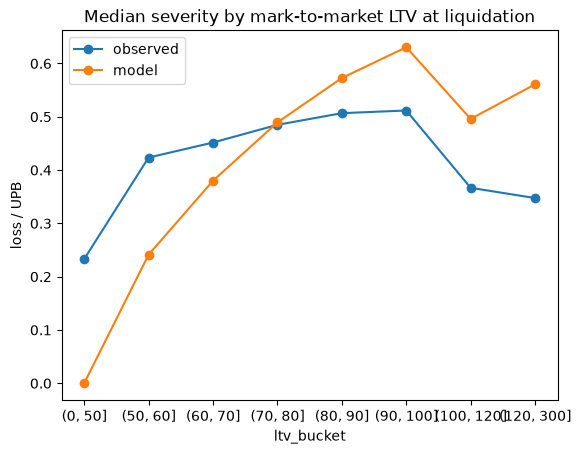

In [9]:
c = fit["credit"]
liq = liq.assign(pred=cal.severity_model(liq.ltv.values, liq.rate.values, liq.has_mi.values, c["costs"], c["reo_discount"], c["liq_lag"], c["mi_coverage"]),
                 ltv_bucket=pd.cut(liq.ltv, [0, 50, 60, 70, 80, 90, 100, 120, 300]))
w = liq.upb
print(f"costs {c['costs']:.1%} of UPB | distressed-sale discount {c['reo_discount']:.1%} | MI pays {c['mi_coverage']:.1%} of claim")
print(f"UPB-weighted severity: observed {np.average(liq.severity, weights=w):.1%}, model {np.average(liq.pred, weights=w):.1%}")
t = liq.groupby("ltv_bucket", observed=True).agg(n=("upb", "size"), observed=("severity", "median"), model=("pred", "median"))
t.plot(y=["observed", "model"], marker="o", title="Median severity by mark-to-market LTV at liquidation"); plt.ylabel("loss / UPB")
t

**Result · Severity fit.** Costs are **10.0%** of UPB and MI pays **18.5%** of the claim (both observed). The fitted distressed-sale discount is **48%** (placeholder: 20%), which means liquidated homes sell far below their HPI-indexed value. With it, the model matches the average observed severity (**44.4% observed vs 45.5% model**).

By LTV, the model fits well at **70–80 LTV** (48% vs 49%), close to STACR's 70.5 WA, but it is **steeper than the data**: it understates losses on very low-LTV loans (the 0–50 bucket loses 23% in the data, 0% in the model) and overstates them above 90 LTV, where mortgage insurance and short sales soften real losses. For STACR's range this is acceptable, but it is worth stating as a limitation.

**Q&A · Severity fit**

**Q: Which parts of severity are observed and which are fitted?**
A: Observed directly from the liquidation records: costs (10.0% of UPB) and MI recoveries (18.5% of the claim). The missed-interest months come from the pipeline timing (19 months). Only the distressed-sale discount is fitted, chosen so the model's UPB-weighted average severity matches the observed one.

**Q: Why does the model miss at low and high LTV?**
A: The model's severity is driven by LTV through the sale proceeds, while the data is flatter. At very low LTV, real liquidations still lose about 23% (costs and missed interest that the model's proceeds more than offset). At high LTV, MI, short sales and loan sales soften real losses. For STACR's 60–80 LTV range, the fit is close.

**Q: Could severity be modeled differently?**
A: Yes, for example with a regression of severity on LTV, loan size, state and disposition type. The structural form was kept so severity responds to HPI scenarios in an explainable way, which matters for stress testing.

## 7 · What changed for STACR: placeholder vs fitted parameters

In [10]:
pool = pd.read_parquet(ROOT / "data" / "processed" / "stacr_dna1.parquet")
N = 53
old_pp = {"turnover": 0.06, "refi_max": 0.55, "midpoint": 0.75, "slope": 3.5, "burnout": 0.02, "ramp_months": 30}
old_cm = {"base_cdr": 0.0020, "b_ltv_low": 0.04, "b_ltv_high": 0.10, "b_fico": 0.012, "b_dti": 0.02, "investor_mult": 1.5,
          "dq30_extra_mdr": 0.01, "dq30_months": 12, "liq_lag": 12, "costs": 0.10, "reo_discount": 0.20,
          "mi_coverage": 0.25, "mod_share": 0.25, "mod_rate_cut": 2.0}

def summary(pp_params, cm_params):
    keep_pp, keep_cm = dict(pp.PARAMS), dict(cm.PARAMS)
    pp.PARAMS.update(pp_params); cm.PARAMS.update(cm_params)
    try:
        res = cp.run_scenarios(pool, cp.placeholder_scenarios(N), N)
    finally:
        pp.PARAMS.update(keep_pp); cm.PARAMS.update(keep_cm)
    rows = {}
    for k, df in res.items():
        smm = (df.prepayments / (df.beginning_balance - df.scheduled_principal)).to_numpy()
        rows[k] = {"CPR yr 1 (%)": pp.smm_to_cpr(smm[:12]).mean() * 100,
                   "end balance ($bn)": df.ending_balance.iloc[-1] / 1e9,
                   "credit events ($mm)": df.defaults.sum() / 1e6, "losses ($mm)": df.losses.sum() / 1e6,
                   "loss / cut-off (%)": df.losses.sum() / cp.CUTOFF_BALANCE * 100,
                   "avg severity (%)": df.losses.sum() / max(df.defaults.sum(), 1) * 100}
    return pd.DataFrame(rows)

before, after = summary(old_pp, old_cm), summary(fit["prepayment"], fit["credit"])
cols = [(s, v) for s in ["good", "base", "moderate", "severe"] for v in ["placeholder", "fitted"]]
pd.concat({"placeholder": before, "fitted": after}, axis=1).swaplevel(axis=1)[cols].round(2)

good                base             moderate  \
                    placeholder  fitted placeholder   fitted placeholder   
CPR yr 1 (%)            37.4600 40.1200     18.9900  21.3800     29.4100   
end balance ($bn)        4.4100  3.2200      7.8500   7.3400      5.2600   
credit events ($mm)     87.8000 96.0100    101.0400 111.1500    105.1500   
losses ($mm)             2.5800 38.8500      3.6600  47.3900     10.5900   
loss / cut-off (%)       0.0100  0.1700      0.0200   0.2100      0.0500   
avg severity (%)         2.9400 40.4600      3.6300  42.6400     10.0700   

                                  severe           
                      fitted placeholder   fitted  
CPR yr 1 (%)         31.0700     36.0500  38.0900  
end balance ($bn)     4.7600      4.3400   3.4600  
credit events ($mm) 108.8500    121.4200 108.3300  
losses ($mm)         54.9300     21.3800  59.8300  
loss / cut-off (%)    0.2400      0.0900   0.2600  
avg severity (%)     50.4600     17.6100  55.2200

**Result · What changed for STACR.** With the same placeholder scenarios:
- **Prepayment** is slightly faster (base year-1 CPR 21% vs 19%), so the pool ends a bit smaller ($7.34bn vs $7.85bn base).
- **Credit events** are similar ($96–111mm vs $88–121mm). A higher base rate, a milder LTV effect and the 57% non-liquidation share roughly offset.
- **Losses are 3–15× higher** (about 13× in the base case, less in the stress cases where the placeholder already had some severity): $39–60mm instead of $3–21mm, or **0.17–0.26%** of cut-off instead of 0.01–0.09%, because severity is now **40–55%** instead of 3–18%.
- The **severe case now just reaches B-2H** (B-3H covers 0–0.25%). A-1, M-1 and M-2 are still untouched.

**Q&A · What changed for STACR**

**Q: How does this cell compare the two parameter sets?**
A: It temporarily loads the placeholder parameters, runs the four scenarios, restores the fitted parameters, runs them again, and shows the results side by side. The scenario paths are the same, so every difference comes from the parameters.

**Q: Which parameter change matters most?**
A: Severity, by far. Credit events are similar ($96–111mm vs $88–121mm), but each liquidated dollar now loses 40–55% instead of 3–18%. That's why losses rise 3–15×.

**Q: Does calibration change the investment conclusion?**
A: Not for the offered notes: even severe losses (0.26%) stay far below the 1.90% where M-2B starts taking losses. It does change the story for Freddie's retained B-3H, which is mostly or fully used in every scenario.

In [11]:
# The placeholder base path assumes a 6.25% mortgage rate. PMMS is now much higher:
today = pmms.iloc[-1]
df = cp.project_collateral(pool, np.linspace(1, 1.15, N + 1), np.full(N, today), N)
smm = (df.prepayments / (df.beginning_balance - df.scheduled_principal)).to_numpy()
print(f"base HPI path at today's PMMS {today:.2f}%: CPR yr 1 {pp.smm_to_cpr(smm[:12]).mean():.1%}, "
      f"end balance ${df.ending_balance.iloc[-1]/1e9:.2f}bn, losses {df.losses.sum()/cp.CUTOFF_BALANCE:.3%} of cut-off")

base HPI path at today's PMMS 7.28%: CPR yr 1 8.1%, end balance $12.64bn, losses 0.231% of cut-off


**Result · Today's rates.** At today's **7.28% PMMS** the pool is about 0.5 pp **out of the money**. Base-case CPR drops to about **8%**, the pool is still **$12.6bn** at the 2031 call, and losses are 0.231% of cut-off. Lower prepayment means **longer note lives and more time for defaults to liquidate** before the call. The placeholder base path (6.25%) is too fast, so Coco's scenarios should start from current PMMS.

**Q&A · Today's rates**

**Q: Why do losses go *up* when rates go up (0.231% vs 0.209%)?**
A: At 7.28% the pool is out of the money, so CPR falls to about 8%. More balance stays in the pool for longer, so more loans have time to default and liquidate before the 2031 call. Slower prepayment means more credit exposure.

**Q: What does this mean for the offered notes?**
A: A much longer life. The pool is still $12.6bn at the call vs $7.3bn in the 6.25% base case, so A-1, M-1 and M-2 stay outstanding longer and earn their spread longer, while carrying more time-at-risk. Coco's base scenario should start from today's PMMS.

## Summary: fitted parameters and what they mean

| Parameter | Placeholder | Fitted | Evidence |
|---|---|---|---|
| turnover | 6% | **5.5%** | CPR out of the money |
| refi_max / slope / midpoint | 55% / 3.5 / 0.75 | **41% / 2.7 / 0.71 pp** | S-curve, R² 0.91 |
| burnout | 0.02 | **0.0076** | CPR vs accumulated incentive |
| seasoning ramp | 30 months | **6 months** | CPR by loan age |
| base default rate | 0.2% | **0.40%** a year | Poisson GLM, post-2008 vintages |
| LTV slope below / above 80 | 4% / 10% per pt | **2.1% / 4.0%** | GLM |
| FICO / DTI / investor | 1.2% / 2% / 1.5× | **0.9% / 2.3% / 1.22×** | GLM |
| 30-day roll extra hazard | 1% a month | **2.28%** | 24.5% reach 90+ in 12 months |
| liquidation lag | 12 months | **19** | 2013+ spells |
| costs / sale discount / MI | 10% / 20% / 25% | **10% / 48% / 18.5%** | 17k liquidations |
| share never liquidated / rate cut | 25% / 2 pp | **57% / 0.57 pp** effective | 90+ outcomes |

**Bottom line for the project.** On real Freddie history, liquidation losses are much larger than equity alone suggests, so the STACR pool's expected loss rises from about 0.02% to **about 0.2% of cut-off** in the base case. That still sits inside Freddie Mac's retained first-loss piece and is far below the 1.90% needed to touch M-2B. The rate environment matters more for the offered notes: at today's 7.28% PMMS, prepayments slow to about 8% CPR and the notes stay outstanding much longer.

**Limits.** National (not state) HPI; a single severity curve for all eras; no negative-equity block on refinancing; placeholder scenario paths until Coco's arrive.